In [ ]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, FIGURES_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
dashed_style = (0, (5, 5))

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def plot_heatmaps(mats, times, titles, norm=None, cmap="hot", figsize=None):
    """Plot [T, N] matrices as side-by-side heatmaps."""
    n = len(mats)

    if figsize is None:
        figsize = (4 * n, 4)

    fig, axes = plt.subplots(
        1, n, figsize=figsize, sharey=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, mat, time, title in zip(axes, mats, times, titles):
        im = ax.imshow(
            mat.T,
            aspect="auto",
            origin="lower",
            extent=[time[0], time[-1], 0, mat.shape[1]],
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    return fig, axes

def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [125]:
tsi = []

sta_awake = []
sta_nrem = []
sta_nrem_all = []

sweeps = []

for mouse_id in MOUSE_IDS:
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  
    sweeps.append(nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sweeps.npz"))
    tsi.append(turn_units['turn_index'])

    sta_awake.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_awake.npz"))
    sta_nrem.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem.npz"))
    sta_nrem_all.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_all.npz"))

tsi = np.concatenate(tsi)
order = np.argsort(tsi)
tsi = tsi[order]

sta_awake = np.rad2deg(np.column_stack(sta_awake))[:, order]
sta_nrem = np.rad2deg(np.column_stack(sta_nrem))[:, order]
sta_nrem_all = np.rad2deg(np.column_stack(sta_nrem_all))[:, order]

sta_original = nap.load_file(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")
tsi_original = np.load(PROCESSED_DIR / "dual" / "tsi_sorted.npy")


nanmask = np.any(np.isnan(sta_nrem), axis=0)
tsi = tsi[~nanmask]
zero_cross = np.argmin(np.abs(tsi)).item()
sta_original = sta_original[:, ~nanmask]
sta_awake = sta_awake[:, ~nanmask]
sta_nrem = sta_nrem[:, ~nanmask]
sta_nrem_all = sta_nrem_all[:, ~nanmask]

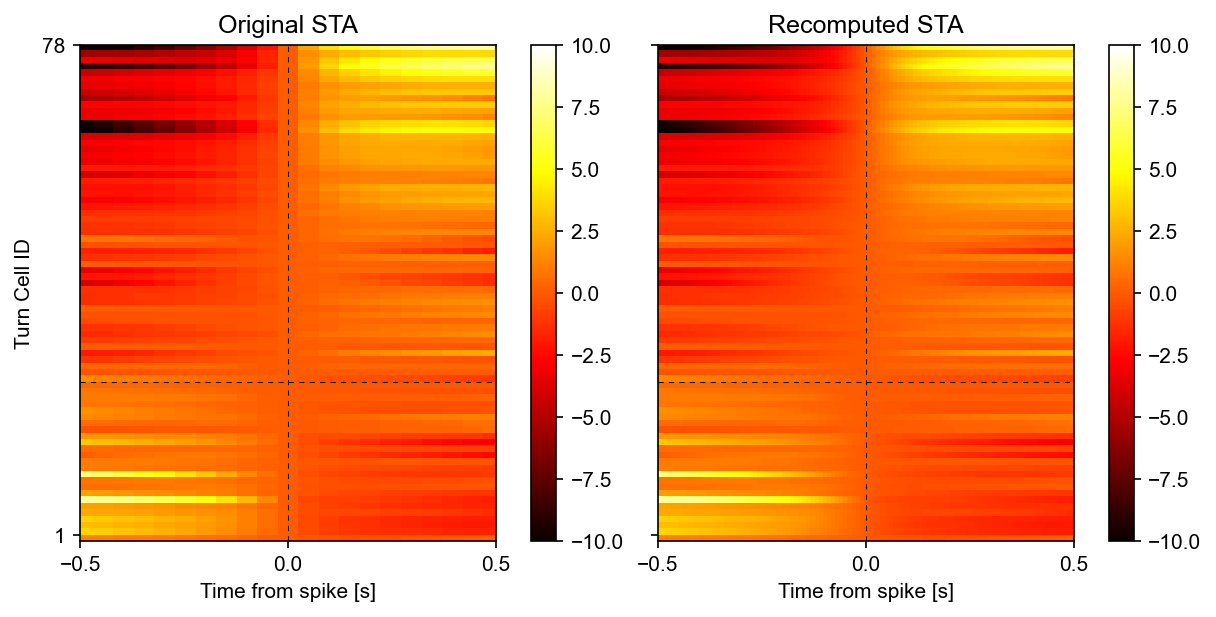

In [129]:
fig, axes = plot_heatmaps(
    mats = [sta_original.values, sta_awake.values],
    times = [sta_original.t, sta_awake.t],
    titles = ["Original STA", "Recomputed STA"],
    norm = norm,
)

for ax in axes:
    ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.axhline(zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, 0, 0.5])
axes[0].set_yticks([1, len(sta_original.columns)])
axes[1].set_xticks([-0.5, 0, 0.5])

plt.savefig(FIGURES_DIR / "sta_comparison.svg", dpi=320)
plt.savefig(FIGURES_DIR / "sta_comparison.png", dpi=320)
plt.show()

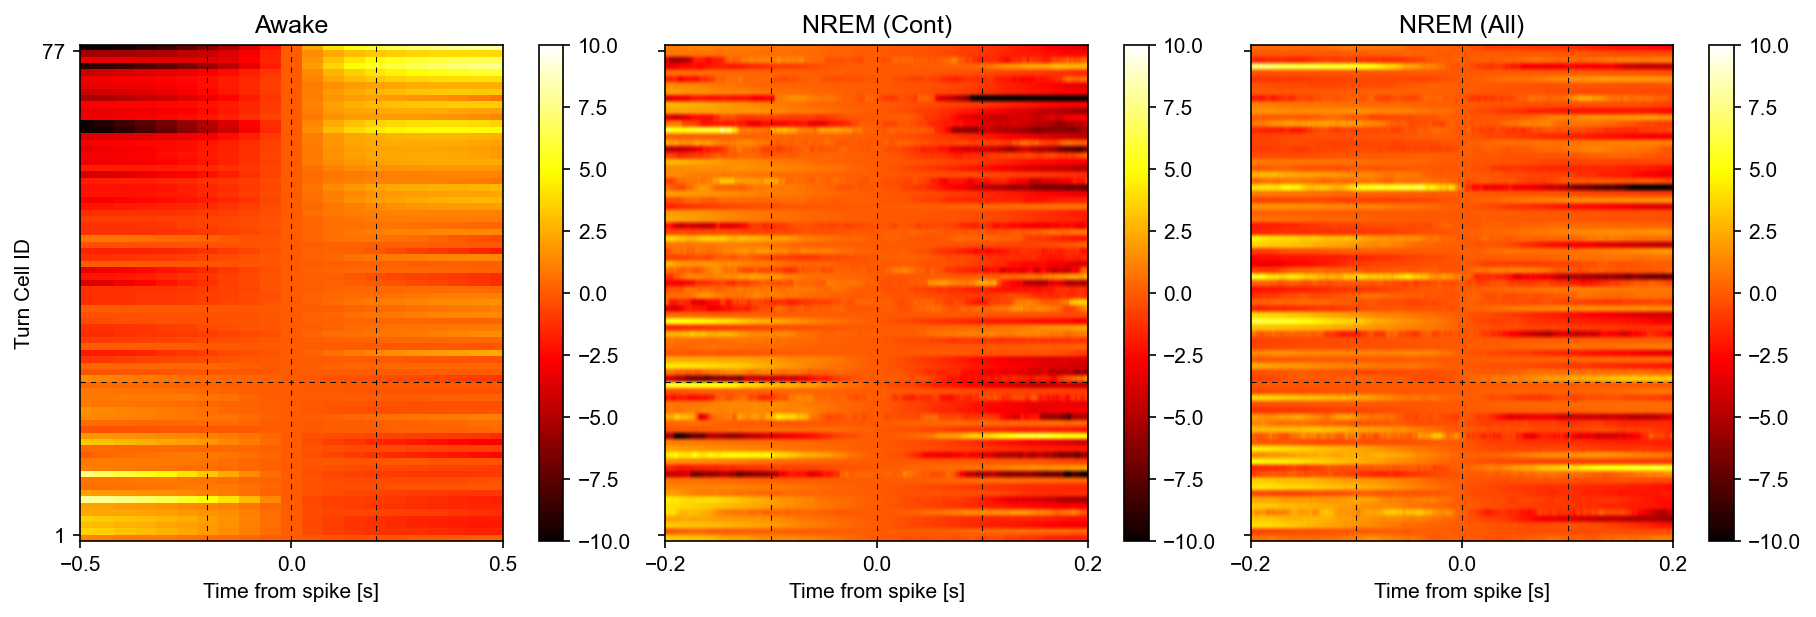

In [153]:
fig, axes = plot_heatmaps(
    mats=[sta_original.d, sta_nrem.d, sta_nrem_all.d],
    times=[sta_original.t, sta_nrem.t, sta_nrem_all.t],
    titles=["Awake", "NREM (Cont)", "NREM (All)"],
    norm=norm,
)

for ax in axes:
    ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.axhline(zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [s]")

axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, 0, 0.5])
axes[0].set_yticks([1, len(sta_original.columns) - 1])

axes[1].set_xticks([-0.2, 0, 0.2])
axes[2].set_xticks([-0.2, 0, 0.2])

axes[0].axvline(0.2, color="k", linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(-0.2, color="k", linestyle=dashed_style, linewidth=0.5)

axes[1].axvline(0.1, color="k", linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(-0.1, color="k", linestyle=dashed_style, linewidth=0.5)

axes[2].axvline(0.1, color="k", linestyle=dashed_style, linewidth=0.5)
axes[2].axvline(-0.1, color="k", linestyle=dashed_style, linewidth=0.5)

plt.savefig(FIGURES_DIR / "sta.svg", dpi=320)
plt.savefig(FIGURES_DIR / "sta.png", dpi=320)

plt.show()

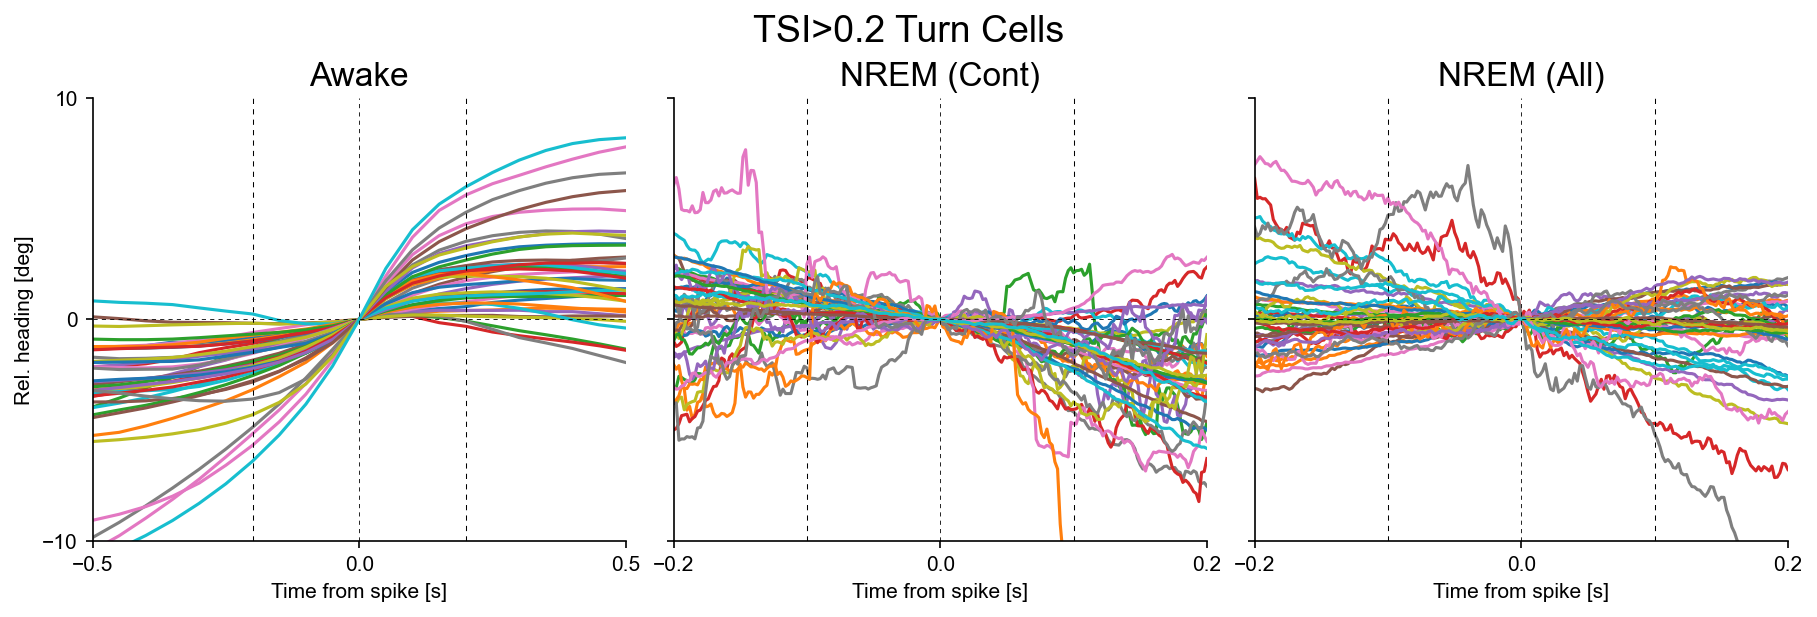

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.flatten()

mask = tsi>0.2
axes[0].plot(sta_original.index, sta_original[:, mask])
axes[0].set_ylabel("Rel. heading [deg]")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_ylim([-10, 10])

axes[0].set_xticks([-0.5, 0, 0.5])
axes[0].set_yticks([-10, 0, 10])

axes[0].axvline(x=0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(x=-0.2, color='k', linestyle=dashed_style, linewidth=0.5)
axes[0].set_title(f"Awake", fontsize=16)

axes[1].plot(sta_nrem.index, sta_nrem[:, mask])
axes[1].set_xlim([-0.2, 0.2])
axes[1].set_xticks([-0.2, 0, 0.2])
axes[1].axvline(x=0.1, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(x=-0.1, color='k', linestyle=dashed_style, linewidth=0.5)
axes[1].set_title(f"NREM (Cont)", fontsize=16)

axes[2].plot(sta_nrem_all.index, sta_nrem_all[:, mask])
axes[2].set_xlim([-0.2, 0.2])
axes[2].set_xticks([-0.2, 0, 0.2])
axes[2].axvline(x=0.1, color='k', linestyle=dashed_style, linewidth=0.5)
axes[2].axvline(x=-0.1, color='k', linestyle=dashed_style, linewidth=0.5)
axes[2].set_title(f"NREM (All)", fontsize=16)


for ax in axes:
    ax.axhline(y=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.axvline(x=0, color='k', linestyle=dashed_style, linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)    
    ax.set_xlabel("Time from spike [s]")

fig.suptitle("TSI>0.2 Turn Cells", fontsize=18)
# plt.savefig(FIGURES_DIR / "sta_cw_turns.png", dpi=320)
# plt.savefig(FIGURES_DIR / "sta_cw_turns.svg", dpi=320)
plt.show()

In [157]:
turn_amps_awake         = amplitude_at_threshold(sta_original, sta_original.t, 0.2)
turn_amps_nrem_all      = amplitude_at_threshold(sta_nrem_all, sta_nrem_all.t, 0.1)
turn_amps_nrem          = amplitude_at_threshold(sta_nrem, sta_nrem.t, 0.1)

Text(0, 0.5, 'NREM amp. [deg]')

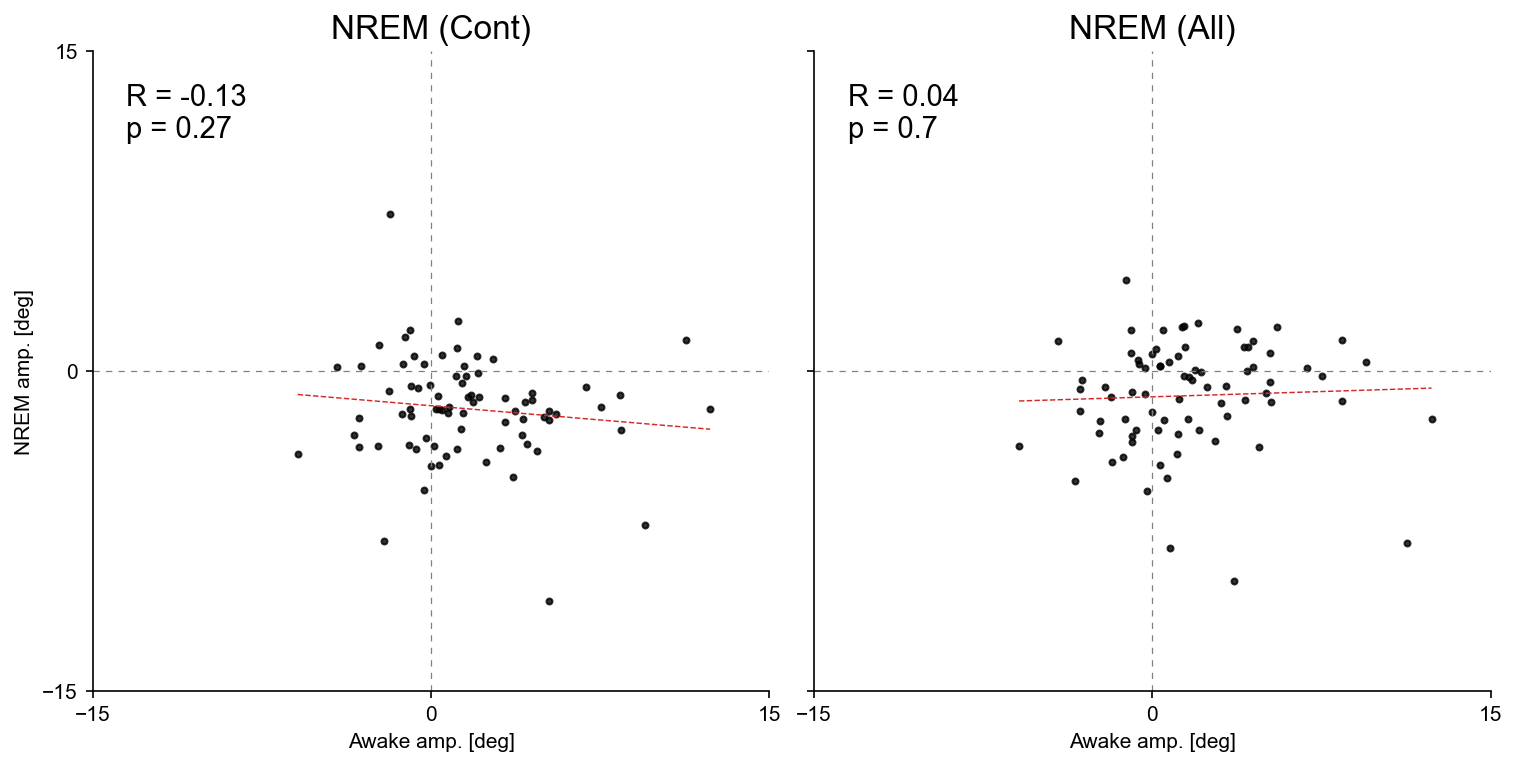

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

for i, (x, y) in enumerate([(turn_amps_awake, turn_amps_nrem), (turn_amps_awake, turn_amps_nrem_all)]):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    axes[i].scatter(x, y, s=8, c='k', alpha=0.8)
    axes[i].plot(x_fit, y_fit, color='tab:red', linewidth=0.7, linestyle='--')
    axes[i].axhline(0, color='0.5', linestyle=dashed_style, linewidth=0.6)
    axes[i].axvline(0, color='0.5', linestyle=dashed_style, linewidth=0.6)

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel("Awake amp. [deg]")

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    axes[i].text(0.05, 0.95, label, transform=axes[i].transAxes, ha='left', va='top', fontsize=14)
    axes[i].set_xticks([-15, 0, 15])
    axes[i].set_yticks([-15, 0, 15])
    axes[i].set_xlim([-15, 15])
    axes[i].set_ylim([-15, 15])

axes[0].set_title("NREM (Cont)", fontsize=16)
axes[1].set_title("NREM (All)", fontsize=16)
axes[0].set_ylabel('NREM amp. [deg]')

plt.savefig(FIGURES_DIR / "turn_scatter.svg", dpi=320)
plt.savefig(FIGURES_DIR / "turn_scatter.png", dpi=320)

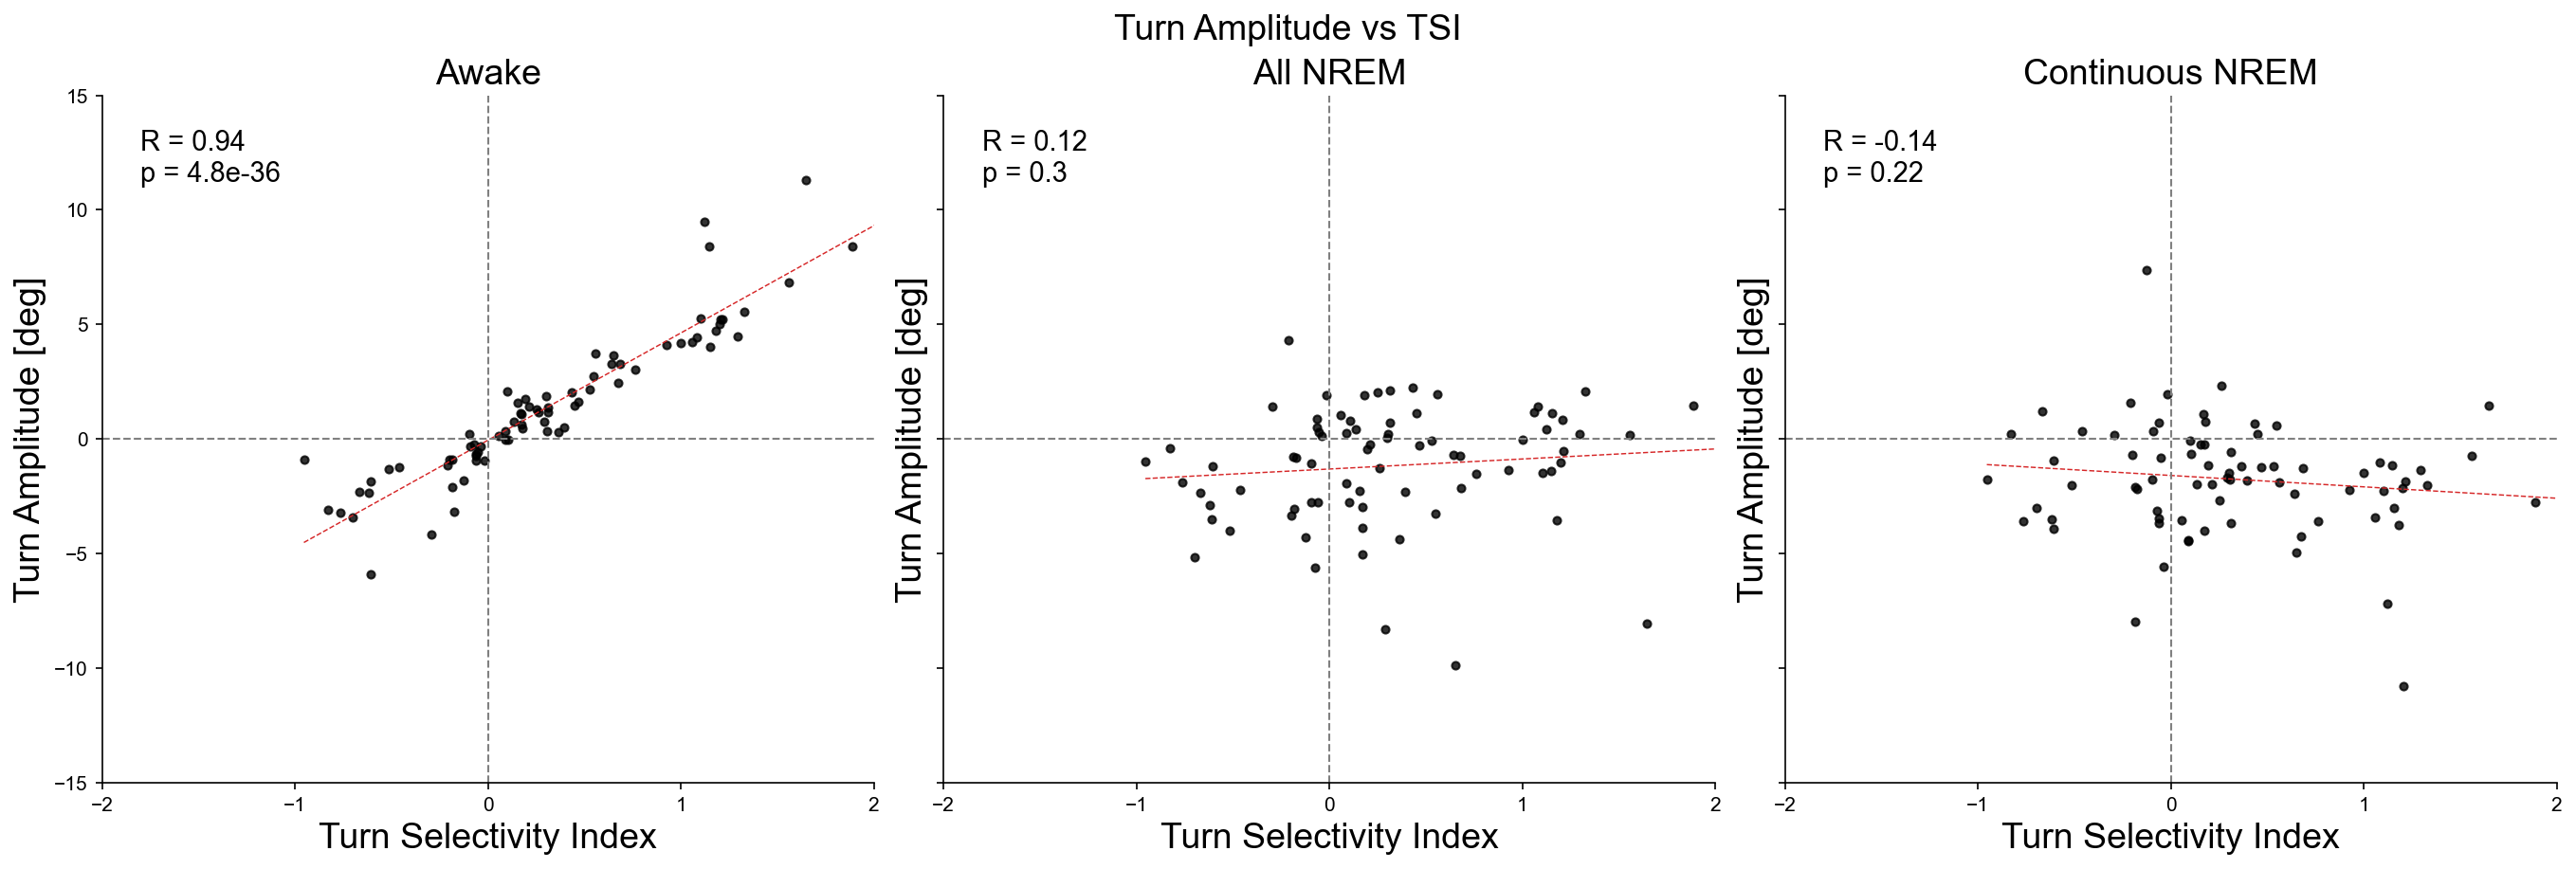

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True)

plot_scatter_with_regression(axes[0], tsi, turn_amps_awake, 'Awake', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[1], tsi, turn_amps_nrem_all, 'All NREM', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')
plot_scatter_with_regression(axes[2], tsi, turn_amps_nrem, 'Continuous NREM', xlabel='Turn Selectivity Index', ylabel='Turn Amplitude [deg]')


for ax in axes:
    ax.set_xlim((-2, 2))
    ax.set_ylim((-15, 15))
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Turn Amplitude vs TSI", fontsize=18)

plt.savefig(FIGURES_DIR / "turn_scatter_tsi.svg", dpi=320)
plt.savefig(FIGURES_DIR / "turn_scatter_tsi.png", dpi=320)

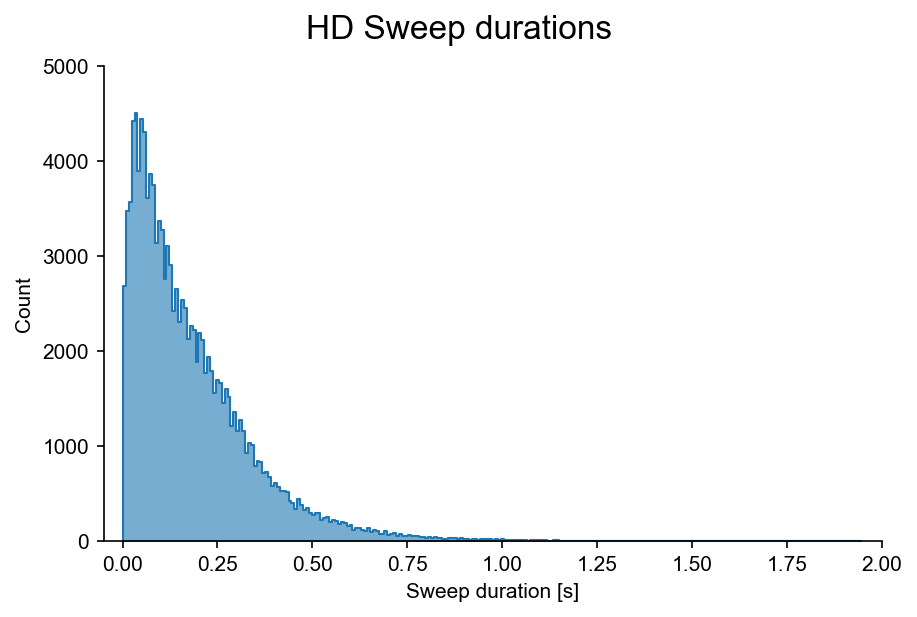

In [114]:
durations_s = np.concatenate([np.diff(sweep.time_support.values, axis=1) for sweep in sweeps])
fig, ax = plt.subplots(figsize=(6, 4))

hist_kwargs = dict(element='step', common_norm=False, fill=True, alpha=0.6, legend=False)

sns.histplot(durations_s, **hist_kwargs, ax=ax)
sns.despine()

ax.set_xlim([-0.05, 2])
ax.set_ylim([0, 5000])
ax.set_xlabel("Sweep duration [s]")

fig.suptitle("HD Sweep durations", fontsize=16)

plt.savefig(FIGURES_DIR / "sweeps_durations.svg", dpi=320)
plt.savefig(FIGURES_DIR / "sweeps_durations.png", dpi=320)